In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


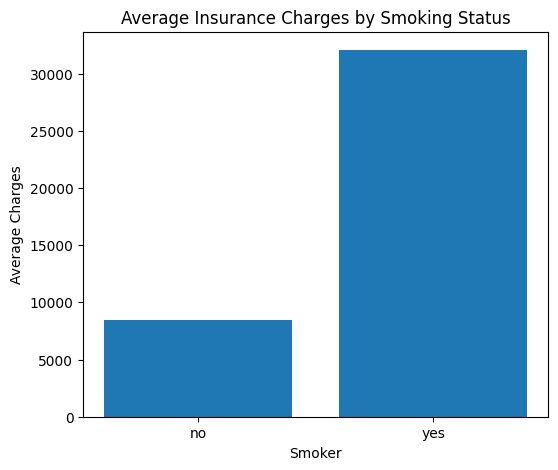

In [ ]:
avg = df.groupby('smoker')['charges'].mean()

plt.figure(figsize=(6,5))

plt.bar(avg.index, avg.values)

plt.xlabel("Smoker")
plt.ylabel("Average Charges")
plt.title("Average Insurance Charges by Smoking Status")

plt.show()

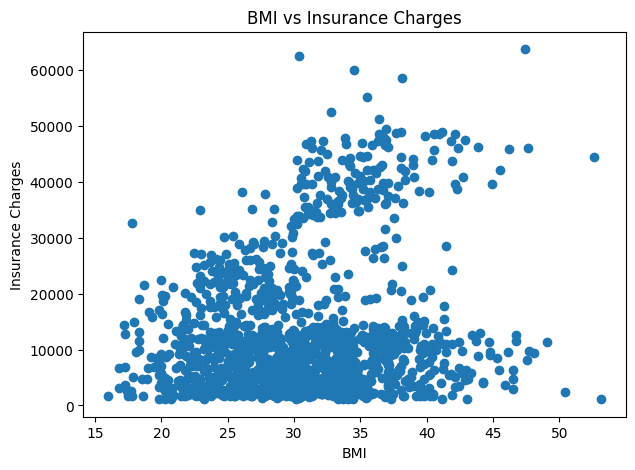

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(df["bmi"], df["charges"])

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")

plt.show()

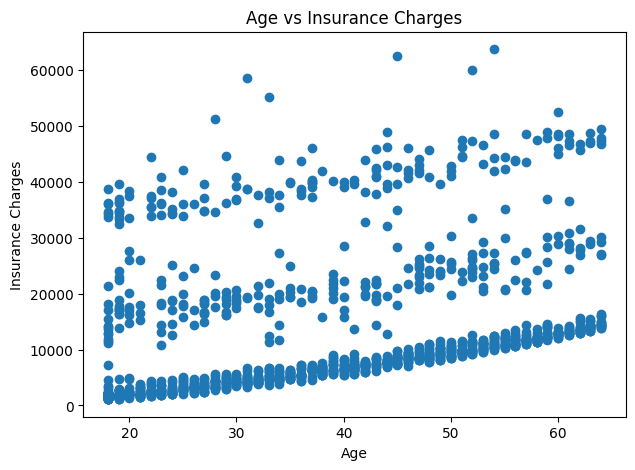

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(df["age"], df["charges"])

plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")

plt.show()

In [ ]:
df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

In [ ]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

MAE: 4181.19447375365
RMSE: 5796.284659276273


In [ ]:
model.score(X_test, y_test)


0.7835929767120724